# 2023년 본예산·최종예산 변동 분석

2023년 정제 문서의 본예산과 2024년 정제 문서에 기록된 2023년 최종예산을 비교한다. 정제 파이프라인과 분석 범위를 분리하기 위해 기존 시도 분리·정제 노트북에서 이동했다.

> 현재 집계·통계 결과는 동명 사업 구성 변화 문제를 반영해 재설계할 예정인 잠정 분석이다.

In [1]:
# 독립 실행 설정: 정제 노트북의 메모리 상태 대신 저장된 long CSV를 읽는다.
import re
from pathlib import Path

import numpy as np
import pandas as pd
from rapidfuzz import fuzz

YEAR = 2023
TARGET_YEAR = 2023
SOURCES = [2023, 2024]

INTERIM_DIR = Path("../data/interim")
LOOKUP_DIR = Path("../data/lookup")
RESULTS_DIR = Path("../results")


def get_sido_dir(sido: str) -> Path:
    """지역별 정제 산출물 폴더 경로를 반환한다."""
    return INTERIM_DIR / sido


sido_lookup = pd.read_csv(LOOKUP_DIR / "시도_지역코드_매핑.csv")
SIDO_LIST = sorted(sido_lookup["지역"].dropna().unique())

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

print("분석 대상 시도:", len(SIDO_LIST))

분석 대상 시도: 17


# 2024_정제 테이블에서의 2023년도 예산과 2023_정제 테이블에서의 예산 비교 
세부사업명 + 사업분류재정구분이 같은 경우, 최종예산과 계획예산이 얼마나 달라졌는지 / 주요내용이 얼마나 달라졌는지 확인 필요

In [2]:
def load_long(sido: str, source_year: int) -> pd.DataFrame:
    return pd.read_csv(get_sido_dir(sido) / f"{source_year}_{sido}_세부사업_정제_long.csv")


def compare_target_year_all_categories(
    target_year: int, sources: list[int], sido_list: list[str] | None = None
) -> pd.DataFrame:
    if sido_list is None:
        sido_list = SIDO_LIST

    frames = []
    for source_year in sources:
        col_name = f"{target_year}년예산_{source_year}년문서"
        rows = []
        for sido in sido_list:
            try:
                df_long = load_long(sido, source_year)
            except FileNotFoundError as e:
                print(f"[건너뜀] {sido}: ({source_year}년 문서): {e}")
                continue
            sub = df_long[df_long["연도"] == target_year][["지역", "세부사업명", "예산액"]].rename(
                columns={"예산액": col_name}
            )
            rows.append(sub)

        frames.append(
            pd.concat(rows, ignore_index=True)
            if rows
            else pd.DataFrame(columns=["지역", "세부사업명", col_name])
        )

    result = frames[0]
    for f in frames[1:]:
        result = result.merge(f, on=["지역", "세부사업명"], how="inner")
        budget_cols = [c for c in result.columns if c.startswith(f"{target_year}년예산_")]
        result["일치"] = result[budget_cols[0]] == result[budget_cols[1]]
    return result

In [3]:
all_comparison = compare_target_year_all_categories(target_year=2023, sources=[2023, 2024])

print("전체 겹치는 세부사업 수: ", len(all_comparison))
print("일치:", all_comparison["일치"].sum(), "/ 불일치:", (~all_comparison["일치"]).sum())

print("\n불일치 상세")
display(all_comparison[~all_comparison["일치"]].groupby("지역").size().sort_values(ascending=False))

전체 겹치는 세부사업 수:  4049
일치: 1907 / 불일치: 2142

불일치 상세


지역
경기    574
전남    201
강원    188
충북    171
부산    163
경남    138
전북    116
인천     97
대구     86
경북     68
울산     65
서울     65
충남     64
세종     41
광주     40
제주     33
대전     32
dtype: int64

In [4]:
all_comparison["예산변동액"] = (
    all_comparison["2023년예산_2024년문서"] - all_comparison["2023년예산_2023년문서"]
)

all_comparison["예산변동률(%)"] = (
    all_comparison["예산변동액"] / all_comparison["2023년예산_2023년문서"].replace(0, np.nan) * 100
)

display(all_comparison.sort_values("예산변동률(%)", key=abs, ascending=False).head(20))

,지역,세부사업명,2023년예산_2023년문서,2023년예산_2024년문서,일치,예산변동액,예산변동률(%)
2337,부산,노인복지관 운영 지원,23.0,23655.0,False,23632.0,102747.826087
348,경기,생계급여 (아동일시보호소),389.0,264283.0,False,263894.0,67839.074550
360,경기,학생생명존중교육 운영,12.0,4217.0,False,4205.0,35041.666667
1003,경기,경로당 운영 지원,87.0,29016.0,False,28929.0,33251.724138
2754,울산,임신직원 지원,3.0,743.0,False,740.0,24666.666667
1053,경기,청년 월세 지원,50.0,11928.0,False,11878.0,23756.000000
897,경기,신생아 출산가구 축하목 등 지원사업,13.0,1760.0,False,1747.0,13438.461538
2004,대전,유초등 돌봄교실 지원,250.0,32507.0,False,32257.0,12902.800000
3669,충남,가정양육수당,79.0,9514.0,False,9435.0,11943.037975
3686,충남,산모신생아 건강관리 지원,79.0,8789.0,False,8710.0,11025.316456


## 세부사업명 + 주요내용 까지 같이 비교
- 세부사업명이 일치하는 항목끼리, 예산변동률뿐만아니라 주요내용 텍스트도 나란히 두고 내용이 달라졌는지 확인한다.

In [5]:
def load_year_detail(sido: str, source_year: int, target_year: int) -> pd.DataFrame:
    """soure_year 문서의 long 파일에서 target_year에 해당하는 예산액과 주요내용을 뽑는다"""
    df_long = load_long(sido, source_year)

    result = df_long.loc[
        df_long["연도"] == target_year,
        [
            "지역",
            "사업분류재정구분",
            "세부사업명",
            "예산액",
            "주요내용",
        ],
    ].copy()

    return result


target_year, sources = 2023, [2023, 2024]
sido_list = SIDO_LIST
group_keys = [
    "지역",
    "사업분류재정구분",
    "세부사업명",
]

frames = []

for source_year in sources:
    rows = []
    for sido in sido_list:
        try:
            sub = load_year_detail(sido, source_year, target_year)
        except FileNotFoundError:
            continue
        rows.append(sub)

    combined = (
        pd.concat(rows, ignore_index=True)
        if rows
        else pd.DataFrame(columns=["지역", "사업분류재정구분", "세부사업명", "예산액", "주요내용"])
    )
    # 같은 지역 공통, 자체, 세부사업명이 여러 행이면 문서별로 먼저 집계함.
    combined = combined.groupby(group_keys, as_index=False, dropna=False).agg(
        예산액=("예산액", lambda x: pd.to_numeric(x, errors="coerce").sum(min_count=1)),
        주요내용=("주요내용", lambda x: " | ".join(pd.unique(x.dropna().astype(str)))),
        구성항목수=("세부사업명", "size"),
    )

    # 문서 출처를 구분할 수 있도록 컬럼명 변경
    combined = combined.rename(
        columns={
            "예산액": f"{target_year}년예산_{source_year}년문서",
            "주요내용": f"주요내용_{source_year}년문서",
            "구성항목수": f"구성항목수_{source_year}년문서",
        }
    )

    frames.append(combined)

detail_comparison = frames[0].merge(frames[1], on=group_keys, how="inner", validate="one_to_one")

initial_budget_col = f"{target_year}년예산_{sources[0]}년문서"
final_budget_col = f"{target_year}년예산_{sources[1]}년문서"

# 지역·공통/자체·세부사업명이 모두 같은 행에서 본예산과 최종예산의 일치 여부를 계산한다.
# 한쪽이라도 결측이면 일치로 보지 않는다.
detail_comparison["본예산_최종예산_일치"] = np.isclose(
    pd.to_numeric(detail_comparison[initial_budget_col], errors="coerce"),
    pd.to_numeric(detail_comparison[final_budget_col], errors="coerce"),
    equal_nan=False,
)

detail_comparison["예산변동률(%)"] = (
    (detail_comparison[final_budget_col] - detail_comparison[initial_budget_col])
    / detail_comparison[initial_budget_col].replace(0, np.nan)
    * 100
)

# 주요 내용 문자열이 달라졌는지 표시
detail_comparison["주요내용_변경"] = (
    detail_comparison[f"주요내용_{sources[0]}년문서"]
    != detail_comparison[f"주요내용_{sources[1]}년문서"]
)
display_cols = [
    "지역",
    "사업분류재정구분",
    "세부사업명",
    f"구성항목수_{sources[0]}년문서",
    f"구성항목수_{sources[1]}년문서",
    initial_budget_col,
    final_budget_col,
    "본예산_최종예산_일치",
    "예산변동률(%)",
    f"주요내용_{sources[0]}년문서",
    f"주요내용_{sources[1]}년문서",
    "주요내용_변경",
]

display(
    detail_comparison.sort_values("예산변동률(%)", key=abs, ascending=False)[display_cols].head(20)
)

,지역,사업분류재정구분,세부사업명,구성항목수_2023년문서,구성항목수_2024년문서,2023년예산_2023년문서,2023년예산_2024년문서,본예산_최종예산_일치,예산변동률(%),주요내용_2023년문서,주요내용_2024년문서,주요내용_변경
295,경기,공통,생계급여 (아동일시보호소),1,1,389.0,264283.0,False,67839.074550,아동일시보호소 입소아동을 보호하기 위해 필요한 생계보호비 지원,입소아동 대상 생계급여 지원,True
318,경기,공통,학생생명존중교육 운영,1,1,12.0,4217.0,False,35041.666667,생명존중 홍보물(생명살림 동영상) 제작 배부 및 생명살림위원회 운영 등,"생명존중 교육자료 매월·배부 및 생명살림 연수 운영, 생명살림위원회 운영 등",True
2381,울산,자체,임신직원 지원,1,1,3.0,743.0,False,24666.666667,임신직원 물품 지원으로 가족 친화적 직장분위기 조성,직원자녀의 건전한 보육 지원 및 후생복지증진,True
631,경기,자체,신생아 출산가구 축하목 등 지원사업,1,1,13.0,1760.0,False,13438.461538,"신생아 출산가구 축하목, 축하화분 지원",지원대상 : 가평군에 주소지를 둔 가구 대상으 로 신생아 출산 가구 지원 지원내용 : 신생아 출산을 축하하기 위한 축하목 및 축하화분 지원,True
1678,대전,자체,유초등 돌봄교실 지원,1,1,250.0,32507.0,False,12902.800000,유치원 및 초등학교 돌봄교실 운영 지원,유치원 및 초등학교 돌봄교실 운영 지원,False
3344,충북,자체,산모신생아 건강관리 지원,1,2,44.0,4654.0,False,10477.272727,,"관내 출산가정에 건강관리사 파견, 서비스 제공 | 지원대상 : 관내 출산부 지원내용 : 본인부담금 발생비용의 90% 지원",True
198,강원,자체,일자리지원센터 운영,1,1,33.0,1970.0,False,5869.696970,근로자 일자리 제공 및 구인 사업체 인력수급을 위한 구직자 구인사업체 매칭 서비스,근로자 일자리 제공 및 구인 사업체 인력수급을 위한 구직자·구인사업체 매칭 서비스,True
942,경기,자체,초등학교 신입생 입학축하금 지원,1,2,15.0,680.0,False,4433.333333,초등학교에 입학하는 아동에게 10만원 지급,초등학교 신입생 입학축하금 지원 | 초등학교에 입학하는아동에게 10만원 지급(1회),True
3497,충북,자체,효행수당 지원,1,2,3.0,74.0,False,2366.666667,"음성군에 1년이상 주소를 두고 거주한 4대 이상 50,000원 지급",3세대 이상 가정으로 효도대상자(만70세이상 노인)와 함께 옥천군에 1년 이상 주소를 두고 거주하는 세대로 효도대상자를 부양하는 자에게 효행수당 5만원 지원 | 지원대상 : 관내 1년 이상 주소를 두고 거주한 4대 이상 가정 지원내용 : 매달5만원효행수당지급,True
2676,전남,자체,노인대학 운영 지원,1,2,19.0,454.0,False,2289.473684,교육을 통한 잠재력 향상 및 활기찬 노후생활,노인대학 운영비 지원 | 관내 거주 60세이상 노인,True


In [6]:
print("세부사업명 + 사업재정분류가 겹치는 세부사업 수: ", len(detail_comparison))
print(
    "본예산_최종예산_일치:",
    detail_comparison["본예산_최종예산_일치"].sum(),
    "/ 본예산_최종예산_불일치:",
    (~detail_comparison["본예산_최종예산_일치"]).sum(),
)

print("\n불일치 상세")
display(
    detail_comparison[~detail_comparison["본예산_최종예산_일치"]]
    .groupby("지역")
    .size()
    .sort_values(ascending=False)
)

세부사업명 + 사업재정분류가 겹치는 세부사업 수:  3499
본예산_최종예산_일치: 1793 / 본예산_최종예산_불일치: 1706

불일치 상세


지역
경기    334
강원    154
전남    154
부산    140
충북    139
경남    125
전북    105
인천     97
대구     85
경북     65
울산     64
서울     63
세종     40
충남     39
광주     38
제주     33
대전     31
dtype: int64

In [7]:
# 퍼지 매칭 적용 - 문자열 유사도 + 숫자 변경 여부 함께 보기
# 기존 '주요내용_변경'은 한 글자만 달라도 True인 완전일치 기준이므로 비교용으로만 보존한다.
# 실제 후속 분석은 아래에서 만드는 '주요내용_실질변경'을 사용한다.

In [8]:
# 텍스트 정규화 - 공백·문장부호·불릿 등 편집 차이를 제거해
# 정책 내용이 같은데 표기만 다른 경우가 변경으로 과대 분류되는 것을 줄인다.
def normalize_for_comparison(text):
    if pd.isna(text):
        return ""

    text = str(text)
    text = re.sub(r"\s+", "", text)
    text = re.sub(r"[·ㆍ•○ㅇ□▪,./:;()\-]", "", text)

    return text


text_2023 = detail_comparison["주요내용_2023년문서"]
text_2024 = detail_comparison["주요내용_2024년문서"]

# NaN과 빈 문자열을 모두 결측로 본다. 결측끼리의 비교를 '일치'로 해석하지 않는다.
missing_2023 = text_2023.isna() | text_2023.fillna("").str.strip().eq("")
missing_2024 = text_2024.isna() | text_2024.fillna("").str.strip().eq("")

detail_comparison["주요내용_자료상태"] = np.select(
    [missing_2023 & missing_2024, missing_2023 | missing_2024],
    ["양쪽 모두 결측", "한쪽만 결측"],
    default="비교 가능",
)

# fuzz.ratio는 정규화된 두 문장의 유사도를 0~100으로 반환한다.
# 한쪽이라도 결측이면 유사도를 계산하지 않고 NaN으로 남겨 '판단 불가'로 구분한다.
detail_comparison["주요내용_유사도"] = [
    fuzz.ratio(normalize_for_comparison(old), normalize_for_comparison(new))
    if not (old_missing or new_missing)
    else np.nan
    for old, new, old_missing, new_missing in zip(text_2023, text_2024, missing_2023, missing_2024)
]

# 유사도 구간은 제출용 판정 기준이 아니라 구간별 표본 검수를 위한 임시 격자이다.
# 첫 경계를 -1로 두어 유사도 0점도 누락 없이 첫 구간에 포함한다.
detail_comparison["주요내용_변경수준"] = pd.cut(
    detail_comparison["주요내용_유사도"],
    bins=[-1, 80, 95, 100],
    labels=["변경 가능성 높음", "검토 필요", "변경 가능성 낮음"],
)


detail_comparison.groupby(
    pd.cut(
        detail_comparison["주요내용_유사도"],
        bins=[-1, 80, 95, 100],
        # labels=["변경 가능성 높음", "검토 필요", "변경 가능성 낮음"],
    ),
    observed=True,
).size()

주요내용_유사도
(-1, 80]     1414
(80, 95]      279
(95, 100]    1707
dtype: int64

In [9]:
# 유사도가 높아도 금액·인원·연령·기간이 달라지면 실질적 변경일 수 있어 숫자를 별도 비교한다.
# 숫자 표기 차이로 인한 오탐을 줄이기 위해 68,020과 68020을 같은 값으로 비교한다.
def extract_comparison_numbers(text):
    if pd.isna(text):
        return []
    return re.findall(r"\d+(?:\.\d+)?", str(text).replace(",", ""))


detail_comparison["주요내용_숫자변경"] = [
    extract_comparison_numbers(old) != extract_comparison_numbers(new)
    if not (old_missing or new_missing)
    else pd.NA
    for old, new, old_missing, new_missing in zip(text_2023, text_2024, missing_2023, missing_2024)
]

# 검토 격자: 단순 True/False 판정 대신 결측·숫자 변경·표현 변경을 구분해 인적 검수 우선순위를 제공한다.
detail_comparison["주요내용_검토구분"] = np.select(
    [
        detail_comparison["주요내용_자료상태"].ne("비교 가능"),
        detail_comparison["주요내용_유사도"].eq(100)
        & detail_comparison["주요내용_숫자변경"].eq(False),
        detail_comparison["주요내용_유사도"].ge(95)
        & detail_comparison["주요내용_숫자변경"].eq(True),
        detail_comparison["주요내용_유사도"].ge(95),
    ],
    [
        "판단 불가",
        "변경없음",
        "숫자 변경 검토",
        "표현 변경 가능성",
    ],
    default="내용 변경 검토",
)

# 95점은 임시 기준이며, 구간별 표본 검수 후 조정해야 한다.
# 표현만 다른 95점 이상은 비변경, 숫자 변경은 실질 변경으로 간주한다.
detail_comparison["주요내용_실질변경"] = np.select(
    [
        detail_comparison["주요내용_자료상태"].ne("비교 가능"),
        detail_comparison["주요내용_검토구분"].isin(["숫자 변경 검토", "내용 변경 검토"]),
    ],
    [np.nan, 1.0],
    default=0.0,
)

detail_comparison.groupby(
    pd.cut(
        detail_comparison["주요내용_유사도"],
        bins=[-1, 60, 80, 90, 95, 99, 100],
    ),
    observed=True,
).size()

주요내용_유사도
(-1, 60]     1056
(60, 80]      358
(80, 90]      170
(90, 95]      109
(95, 99]      111
(99, 100]    1596
dtype: int64

## 시각화 
- 예산변동률 전체 분포를 보고, 주요내용_변경 여부에 따라 변동폭이 다르게 나타나는지 비교 
- 주요내용 변경 여부와 예산변동 사이에 실제로 관련성이 있는가를 확인

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Seaborn 스타일을 먼저 적용해야 한글 폰트 설정이 덮어쓰여지지 않음
sns.set_style("whitegrid")
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
FIG_SIZE = (18, 7)  # (가로, 세로), inch

PALETTE = sns.color_palette("colorblind")

In [11]:
# 분석 모집단 제한:
# 1) 본예산이 0이어서 변동률의 분모가 0인 행
# 2) 주요내용이 한쪽 또는 양쪽 결측이어서 실질 변경을 판단할 수 없는 행
# 위 행은 0이나 '변경 없음'으로 대체하지 않고 후속 비교에서 제외한다.
plot_df = detail_comparison.dropna(subset=["예산변동률(%)", "주요내용_실질변경"]).copy()
plot_df["주요내용_실질변경"] = plot_df["주요내용_실질변경"].astype(bool)

# 극단값이 히스토그램을 압도하지 않도록 표시범위만 클리핑
clip_range = 200
n_clipped = (
    (plot_df["예산변동률(%)"] < -clip_range) | (plot_df["예산변동률(%)"] > clip_range)
).sum()

plot_df["예산변동률_표시용"] = plot_df["예산변동률(%)"].clip(-clip_range, clip_range)

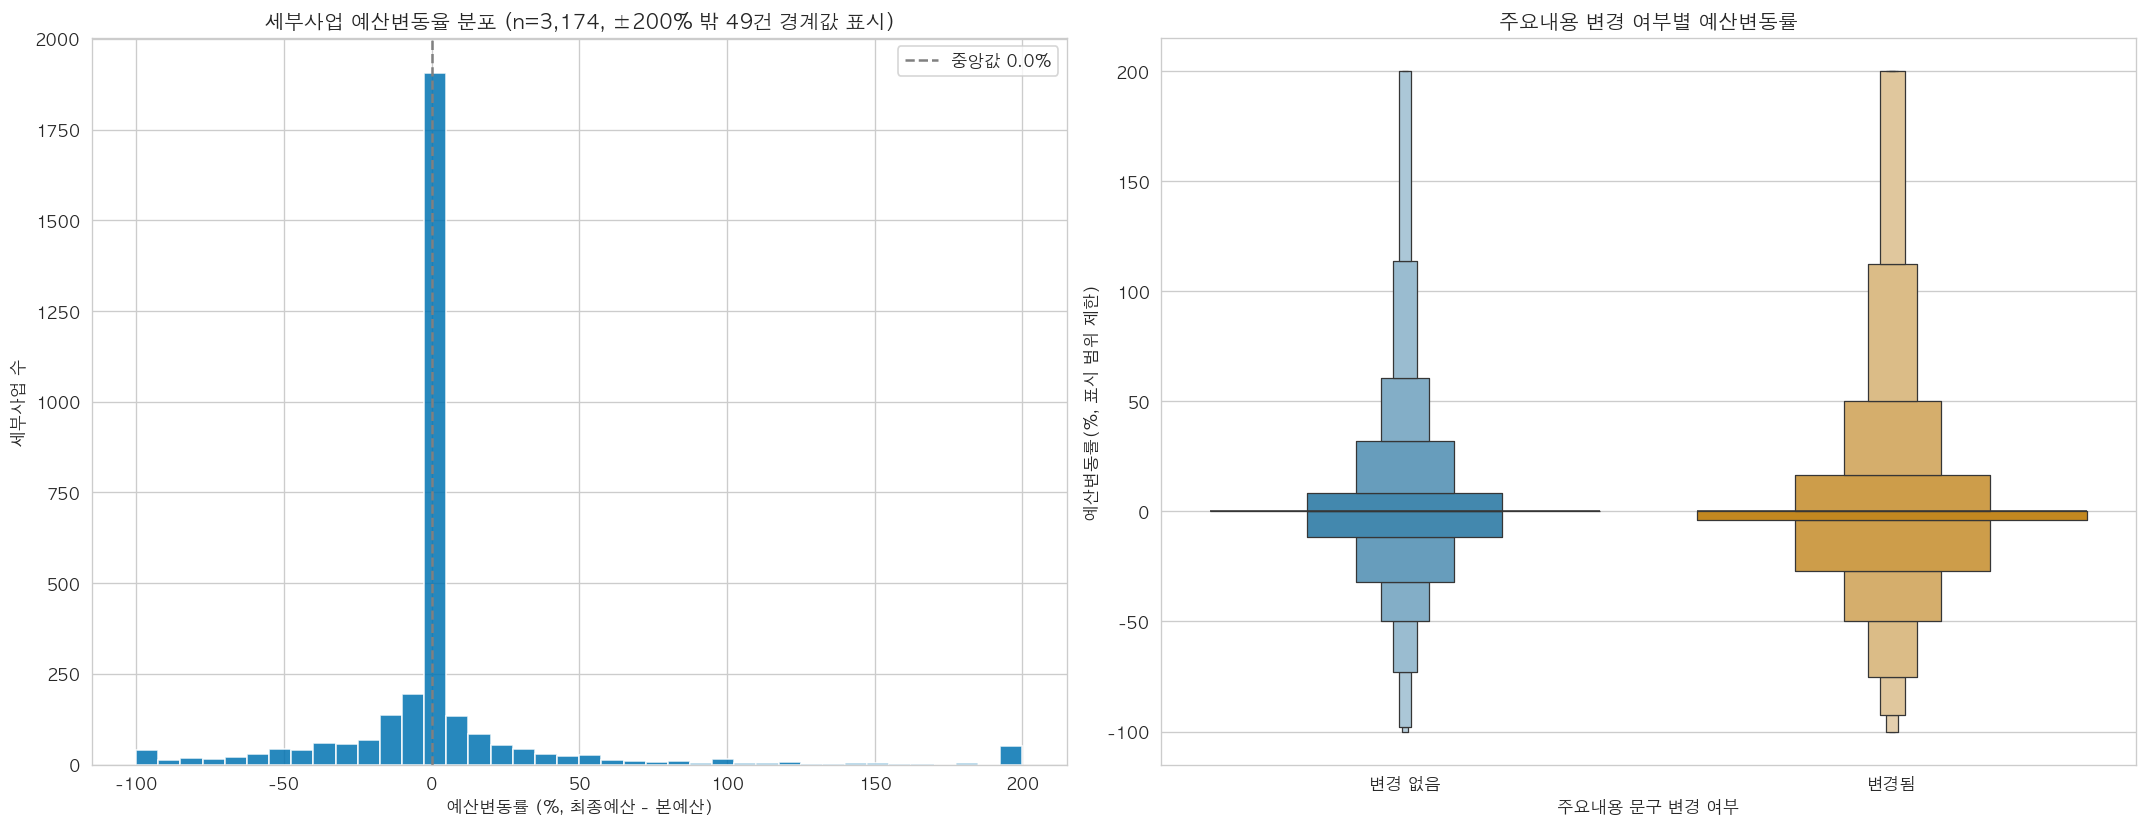

            count   mean  50%     std
주요내용_실질변경                            
False      1537.0   15.6  0.0   365.5
True       1637.0  100.6  0.0  2016.6


In [12]:
fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)

median_val = plot_df["예산변동률(%)"].median()

# 전체 분포
axes[0].hist(plot_df["예산변동률_표시용"], bins=40, color=PALETTE[0], edgecolor="white", alpha=0.85)
axes[0].axvline(0, color="gray", linestyle="--", linewidth=1.5, label=f"중앙값 {median_val:.1f}%")
axes[0].set_title(
    f"세부사업 예산변동율 분포 (n={len(plot_df):,}, ±{clip_range}% 밖 {n_clipped}건 경계값 표시)"
)
axes[0].set_xlabel("예산변동률 (%, 최종예산 - 본예산)")
axes[0].set_ylabel("세부사업 수")
axes[0].legend()

# 주요내용 변경 여부별 비교
sns.boxenplot(
    data=plot_df,
    x="주요내용_실질변경",
    y="예산변동률_표시용",
    hue="주요내용_실질변경",
    order=[False, True],
    hue_order=[False, True],
    palette=PALETTE[:2],
    legend=False,
    ax=axes[1],
)
axes[1].set_title("주요내용 변경 여부별 예산변동률")
axes[1].set_xlabel("주요내용 문구 변경 여부")
axes[1].set_ylabel("예산변동률(%, 표시 범위 제한)")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["변경 없음", "변경됨"])

plt.tight_layout()

out_path = RESULTS_DIR
out_path.mkdir(exist_ok=True)
plt.savefig(
    out_path / f"{YEAR}_에산변동률_분포.png", dpi=150, bbox_inches="tight", facecolor="white"
)

plt.show()

print(
    plot_df.groupby("주요내용_실질변경")["예산변동률(%)"]
    .describe()[["count", "mean", "50%", "std"]]
    .round(1)
)

-> 주요내용 변경 집단은 변경 없음 집단보다 평균 예산 변동률과 변동성이 크게 나타났으나 두 집단의 중앙값은 모두 0.

-> 변경 집단에 큰 폭의 예산 조정 사례가 더 크게 포함되었을 가능성이 높음

-> 통계적 유의성과 실질적 효과를 판단하려면 변동 발생 비율, 절대 변동률 및 효과 크기에 대한 추가 검정 필요

-> 따라서 위의 결과만 보고서는 주요내용이 변경된 사업의 예산변동률이 통계적으로 더 크다고 확정하기 어려움

In [13]:
zero_summary = (
    plot_df.assign(변동없음=plot_df["예산변동률(%)"].eq(0))
    .groupby("주요내용_실질변경")
    .agg(
        전체사업수=("예산변동률(%)", "size"),
        변동없음수=("변동없음", "sum"),
        변동없음비율=("변동없음", "mean"),
        최소값=("예산변동률(%)", "min"),
        중앙값=("예산변동률(%)", "median"),
        최대값=("예산변동률(%)", "max"),
    )
)

zero_summary["변동없음비율"] *= 100
zero_summary.round(1)

,전체사업수,변동없음수,변동없음비율,최소값,중앙값,최대값
주요내용_실질변경,,,,,,
False,1537,836,54.4,-100.0,0.0,12902.8
True,1637,710,43.4,-100.0,0.0,67839.1


In [14]:
direction = np.select(
    [
        plot_df["예산변동률(%)"] < 0,
        plot_df["예산변동률(%)"] > 0,
    ],
    ["감액", "증액"],
    default="변동없음",
)  # 예산변동 방향 분류

direction_table = (
    pd.crosstab(
        plot_df["주요내용_실질변경"].map(
            {
                False: "변경없음",
                True: "변경됨",
            }
        ),
        direction,
        normalize="index",
    )
    .mul(100)
    .round(1)
)

direction_table = direction_table.reindex(columns=["감액", "변동없음", "증액"]).rename_axis(
    index="주요내용 변경 여부", columns="집단 내 예산변동 비율(%)"
)

direction_table

집단 내 예산변동 비율(%),감액,변동없음,증액
주요내용 변경 여부,,,
변경됨,31.2,43.4,25.5
변경없음,23.9,54.4,21.7


In [15]:
plot_df["예산변동_여부"] = np.where(plot_df["예산변동률(%)"] == 0, "변동없음", "변동있음")

contingency_table = pd.crosstab(plot_df["주요내용_실질변경"], plot_df["예산변동_여부"])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(contingency_table)
print(f"카이제곱 통계량: {chi2:.2f}")
print(f"p-value: {p_value:.4f}")

예산변동_여부    변동없음  변동있음
주요내용_실질변경            
False       836   701
True        710   927
카이제곱 통계량: 38.09
p-value: 0.0000


->  주요내용 변경 여부와 예산변동 발생 여부 간에는 통계적으로 유의한 관련성이 확인됨. 